# 📱 Customer Churn Prediction — Telecom

**Business objective:** Identify customers at risk of canceling their service contract, enabling the retention team to act proactively and reduce revenue loss.

---

## Project Structure

| Section | Content |
|---|---|
| 1. Data Loading & Integration | Merge 4 data sources by customer ID |
| 2. Exploratory Data Analysis | Churn drivers by contract, payment, services |
| 3. Feature Engineering | Encoding, scaling, data leakage prevention |
| 4. Modeling | Baseline → Random Forest → XGBoost |
| 5. Evaluation | ROC-AUC, Recall, F1-Score comparison |
| 6. Business Conclusions | Key findings and retention recommendations |

**Dataset:** 4 CSV files (contract, internet, personal, phone) — telecom company  
**Author:** David Encinas Basurto, PhD  
**Stack:** Python · pandas · scikit-learn · XGBoost · matplotlib


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:

# Cargar los 4 archivos CSV
df1 = pd.read_csv('contract.csv')
df2 = pd.read_csv('internet.csv')
df3 = pd.read_csv('personal.csv')
df4 = pd.read_csv('phone.csv')

In [4]:
# Fusionar todos los dataframes basándote en el ID    #usamos outer para no perder ningún registro, aunque no tenga coincidencia en los otros dataframes
df_merged = df1.merge(df2, on='customerID', how='outer') \
               .merge(df3, on='customerID', how='outer') \
               .merge(df4, on='customerID', how='outer')

In [5]:
df_merged.head()
print(f"Registros coincidentes: {len(df_merged)}")
print(df_merged.info())

Registros coincidentes: 7043
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   BeginDate         7043 non-null   str    
 2   EndDate           7043 non-null   str    
 3   Type              7043 non-null   str    
 4   PaperlessBilling  7043 non-null   str    
 5   PaymentMethod     7043 non-null   str    
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   str    
 8   InternetService   5517 non-null   str    
 9   OnlineSecurity    5517 non-null   str    
 10  OnlineBackup      5517 non-null   str    
 11  DeviceProtection  5517 non-null   str    
 12  TechSupport       5517 non-null   str    
 13  StreamingTV       5517 non-null   str    
 14  StreamingMovies   5517 non-null   str    
 15  gender            7043 non-null   str    
 16  SeniorCitizen     7043 n

In [6]:

print(df_merged[['PaymentMethod']].describe())
print(df_merged[['PaymentMethod']].value_counts())

           PaymentMethod
count               7043
unique                 4
top     Electronic check
freq                2365
PaymentMethod            
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


In [7]:
# Ver estadísticas del merge
print(f"Total de registros: {len(df_merged)}")
print(f"Columnas: {df_merged.columns.tolist()}")
print(f"\nValores faltantes por columna:")
print(df_merged.isnull().sum())

# Ver los primeros registros
df_merged.head(10)

Total de registros: 7043
Columnas: ['customerID', 'BeginDate', 'EndDate', 'Type', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'MultipleLines']

Valores faltantes por columna:
customerID             0
BeginDate              0
EndDate                0
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
InternetService     1526
OnlineSecurity      1526
OnlineBackup        1526
DeviceProtection    1526
TechSupport         1526
StreamingTV         1526
StreamingMovies     1526
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
MultipleLines        682
dtype: int64


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,gender,SeniorCitizen,Partner,Dependents,MultipleLines
0,0002-ORFBO,2019-05-01,No,One year,Yes,Mailed check,65.60,593.3,DSL,No,Yes,No,Yes,Yes,No,Female,0,Yes,Yes,No
1,0003-MKNFE,2019-05-01,No,Month-to-month,No,Mailed check,59.90,542.4,DSL,No,No,No,No,No,Yes,Male,0,No,No,Yes
2,0004-TLHLJ,2019-09-01,2020-01-01 00:00:00,Month-to-month,Yes,Electronic check,73.90,280.85,Fiber optic,No,No,Yes,No,No,No,Male,0,No,No,No
3,0011-IGKFF,2018-12-01,2020-01-01 00:00:00,Month-to-month,Yes,Electronic check,98.00,1237.85,Fiber optic,No,Yes,Yes,No,Yes,Yes,Male,1,Yes,No,No
4,0013-EXCHZ,2019-09-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,83.90,267.4,Fiber optic,No,No,No,Yes,Yes,No,Female,1,Yes,No,No
5,0013-MHZWF,2019-05-01,No,Month-to-month,Yes,Credit card (automatic),69.40,571.45,DSL,No,No,No,Yes,Yes,Yes,Female,0,No,Yes,No
6,0013-SMEOE,2014-03-01,No,Two year,Yes,Bank transfer (automatic),109.70,7904.25,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Female,1,Yes,No,No
7,0014-BMAQU,2014-11-01,No,Two year,Yes,Credit card (automatic),84.65,5377.8,Fiber optic,Yes,No,No,Yes,No,No,Male,0,Yes,No,Yes
8,0015-UOCOJ,2019-07-01,No,Month-to-month,Yes,Electronic check,48.20,340.35,DSL,Yes,No,No,No,No,No,Female,1,No,No,No
9,0016-QLJIS,2014-09-01,No,Two year,Yes,Mailed check,90.45,5957.9,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Female,0,Yes,Yes,Yes


In [8]:
# 3. CREAR EL TARGET (Antes de limpiar fechas)
# Si EndDate no es 'No', el cliente se fue (1), si es 'No', sigue activo (0)
df_merged['Churn'] = (df_merged['EndDate'] != 'No').astype(int)

# 4. CORRECCIÓN DE LA FUGA DE DATOS (Data Leakage)
# Definimos la fecha de corte del dataset (Feb 1, 2020)
snapshot_date = pd.to_datetime('2020-02-01')

# Convertimos BeginDate a datetime
df_merged['BeginDate'] = pd.to_datetime(df_merged['BeginDate'])

# IMPORTANTE: Calculamos la duración usando SOLO la fecha de corte para todos.
# No usamos EndDate para los que se fueron, porque el modelo no debería saber esa fecha.
df_merged['duration'] = (snapshot_date - df_merged['BeginDate']).dt.days

# 5. LIMPIEZA DE TOTALCHARGES
# Hay espacios en blanco en TotalCharges para clientes nuevos, los pasamos a 0
df_merged['TotalCharges'] = df_merged['TotalCharges'].replace(' ', '0')
df_merged['TotalCharges'] = pd.to_numeric(df_merged['TotalCharges'])

# 6. ELIMINAR COLUMNAS PROHIBIDAS
# Según el revisor, una vez calculada la duración y el target, 
# las fechas y el ID deben desaparecer para que el modelo no haga "trampa".
df_merged.drop(['customerID', 'BeginDate', 'EndDate'], axis=1, inplace=True)

# 7. RELLENAR NULOS (De los servicios que no todos tienen)
df_merged.fillna('No', inplace=True)

print("Preprocesamiento completado sin fuga de datos.")
print(df_merged.head())

Preprocesamiento completado sin fuga de datos.
             Type PaperlessBilling     PaymentMethod  MonthlyCharges  \
0        One year              Yes      Mailed check            65.6   
1  Month-to-month               No      Mailed check            59.9   
2  Month-to-month              Yes  Electronic check            73.9   
3  Month-to-month              Yes  Electronic check            98.0   
4  Month-to-month              Yes      Mailed check            83.9   

   TotalCharges InternetService OnlineSecurity OnlineBackup DeviceProtection  \
0        593.30             DSL             No          Yes               No   
1        542.40             DSL             No           No               No   
2        280.85     Fiber optic             No           No              Yes   
3       1237.85     Fiber optic             No          Yes              Yes   
4        267.40     Fiber optic             No           No               No   

  TechSupport StreamingTV StreamingMovi

In [9]:
df_merged.head()

,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,gender,SeniorCitizen,Partner,Dependents,MultipleLines,Churn,duration
0,One year,Yes,Mailed check,65.6,593.30,DSL,No,Yes,No,Yes,Yes,No,Female,0,Yes,Yes,No,0,276
1,Month-to-month,No,Mailed check,59.9,542.40,DSL,No,No,No,No,No,Yes,Male,0,No,No,Yes,0,276
2,Month-to-month,Yes,Electronic check,73.9,280.85,Fiber optic,No,No,Yes,No,No,No,Male,0,No,No,No,1,153
3,Month-to-month,Yes,Electronic check,98.0,1237.85,Fiber optic,No,Yes,Yes,No,Yes,Yes,Male,1,Yes,No,No,1,427
4,Month-to-month,Yes,Mailed check,83.9,267.40,Fiber optic,No,No,No,Yes,Yes,No,Female,1,Yes,No,No,1,153


In [10]:
print("\nEjemplos:")
print(df_merged[['Churn']].head(10))


Ejemplos:
   Churn
0      0
1      0
2      1
3      1
4      1
5      0
6      0
7      0
8      0
9      0


In [11]:
print("Distribución de cancelaciones:")        
print(df_merged['Churn'].value_counts())
print(f"\nTasa de churn: {(df_merged['Churn'] == 1).sum() / len(df_merged) * 100:.2f}%")       #0 = No(activo), 1 = Yes (cancelo) 

Distribución de cancelaciones:
Churn
0    5174
1    1869
Name: count, dtype: int64

Tasa de churn: 26.54%


In [12]:
# Analizar los valores faltantes
print("=== ANALISIS DE VALORES FALTANTES ===\n")

# 1. Revisar qué clientes tienen faltantes en internet
print("Clientes sin InternetService:")
sin_internet = df_merged[df_merged['InternetService'].isna()]
print(f"Total: {len(sin_internet)}")
print(f"Churn en clientes sin Internet: {sin_internet['Churn'].mean():.2%}")

# 2. Revisar MultipleLines
print("\nClientes sin MultipleLines:")
sin_multilines = df_merged[df_merged['MultipleLines'].isna()]
print(f"Total: {len(sin_multilines)}")
print(f"Churn sin MultipleLines: {sin_multilines['Churn'].mean():.2%}")

# 3. Tratamiento de valores faltantes
# Para servicios de Internet, reemplazar con 'No service'
internet_cols = ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in internet_cols:
    df_merged[col] = df_merged[col].fillna('No service')

# Para MultipleLines, reemplazar con 'No phone service'
df_merged['MultipleLines'] = df_merged['MultipleLines'].fillna('No phone service')

# Verificar que no hay faltantes
print("\nValores faltantes después de tratamiento:")
print(df_merged.isnull().sum().sum())



=== ANALISIS DE VALORES FALTANTES ===

Clientes sin InternetService:
Total: 0
Churn en clientes sin Internet: nan%

Clientes sin MultipleLines:
Total: 0
Churn sin MultipleLines: nan%

Valores faltantes después de tratamiento:
0


**Handling missing values:** We replace NaN with 'No service' or 'No phone service' to indicate the customer does not have that service. This is standard practice for telecom datasets where services are optional add-ons.

In [13]:
# 1. Distribución por tipo de contrato
print("=== CONTRATOS ===")
print(df_merged['Type'].value_counts())
print("\nChurn por tipo de contrato:")
print(df_merged.groupby('Type')['Churn'].agg(['sum', 'count', 'mean'])) #sum = cantidad de churn, count = total de clientes, mean = tasa de churn

=== CONTRATOS ===
Type
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

Churn por tipo de contrato:
                 sum  count      mean
Type                                 
Month-to-month  1655   3875  0.427097
One year         166   1473  0.112695
Two year          48   1695  0.028319


**Finding:** Month-to-month contract customers show significantly higher churn rates than annual or two-year contract customers. This variable will likely carry strong predictive weight in the model.

In [14]:
# 2. Distribución por tipo de internet
print("\n=== INTERNET ===")
print(df_merged['InternetService'].value_counts())
print("\nChurn por tipo de internet:")
print(df_merged.groupby('InternetService')['Churn'].agg(['sum', 'count', 'mean']))



=== INTERNET ===
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Churn por tipo de internet:
                  sum  count      mean
InternetService                       
DSL               459   2421  0.189591
Fiber optic      1297   3096  0.418928
No                113   1526  0.074050


**Finding:** Internet service type also appears to influence churn probability. Fiber optic customers show higher churn rates, possibly due to higher monthly charges associated with that service.

In [15]:
# 3. Distribución por método de pago
print("\n=== METODO DE PAGO ===")
print(df_merged['PaymentMethod'].value_counts())
print("\nChurn por método de pago:")
print(df_merged.groupby('PaymentMethod')['Churn'].agg(['sum', 'count', 'mean']))


=== METODO DE PAGO ===
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

Churn por método de pago:
                            sum  count      mean
PaymentMethod                                   
Bank transfer (automatic)   258   1544  0.167098
Credit card (automatic)     232   1522  0.152431
Electronic check           1071   2365  0.452854
Mailed check                308   1612  0.191067


In [16]:
# 4. Servicios adicionales y churn
print("\n=== SERVICIOS ADICIONALES ===")
servicios = ['OnlineSecurity', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'OnlineBackup', 'DeviceProtection']
for servicio in servicios:
    print(f"\n{servicio}:")
    print(df_merged.groupby(servicio)['Churn'].mean())




=== SERVICIOS ADICIONALES ===

OnlineSecurity:
OnlineSecurity
No     0.313296
Yes    0.146112
Name: Churn, dtype: float64

TechSupport:
TechSupport
No     0.311862
Yes    0.151663
Name: Churn, dtype: float64

StreamingTV:
StreamingTV
No     0.243312
Yes    0.300702
Name: Churn, dtype: float64

StreamingMovies:
StreamingMovies
No     0.243795
Yes    0.299414
Name: Churn, dtype: float64

OnlineBackup:
OnlineBackup
No     0.291721
Yes    0.215315
Name: Churn, dtype: float64

DeviceProtection:
DeviceProtection
No     0.286518
Yes    0.225021
Name: Churn, dtype: float64


In [17]:
# 5. Variables numéricas
print("\n=== VARIABLES NUMERICAS ===")
print(df_merged[['MonthlyCharges', 'TotalCharges', 'Churn']].groupby('Churn').describe())

# 6. Demografía
print("\n=== DEMOGRAFIA ===")
print("Churn por género:")
print(df_merged.groupby('gender')['Churn'].mean())
print("\nChurn por SeniorCitizen:")
print(df_merged.groupby('SeniorCitizen')['Churn'].mean())


=== VARIABLES NUMERICAS ===
      MonthlyCharges                                                    \
               count       mean        std    min    25%     50%   75%   
Churn                                                                    
0             5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4   
1             1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2   

              TotalCharges                                                    \
          max        count         mean          std    min    25%       50%   
Churn                                                                          
0      118.75       5174.0  2549.911442  2329.954215   0.00  572.9  1679.525   
1      118.35       1869.0  1531.796094  1890.822994  18.85  134.5   703.550   

                         
           75%      max  
Churn                    
0      4262.85  8672.45  
1      2331.30  8684.80  

=== DEMOGRAFIA ===
Churn por género:
gender
Female    0.269209
Male 

---
## 3. Feature Engineering & Preprocessing

> **Key decision — Data Leakage prevention:** We calculate customer duration using only a snapshot date (Feb 1, 2020), not the actual end date. This ensures the model cannot "see the future" during training.

We separate categorical and numerical variables for different preprocessing steps:
- **Categorical** (Type, InternetService, PaymentMethod, etc.) → Label Encoding
- **Numerical** (MonthlyCharges, TotalCharges, duration) → StandardScaler

In [18]:


df_merged['TotalCharges'] = df_merged['TotalCharges'].replace(' ', None)
df_merged['TotalCharges'] = pd.to_numeric(df_merged['TotalCharges'], errors='coerce')

In [19]:
df_merged[['MonthlyCharges','TotalCharges','Churn']].corr()

,MonthlyCharges,TotalCharges,Churn
MonthlyCharges,1.000000,0.651174,0.193356
TotalCharges,0.651174,1.000000,-0.198324
Churn,0.193356,-0.198324,1.000000


**Note on correlation:** MonthlyCharges and TotalCharges show low direct correlation with churn as isolated variables. However, they interact with contract type and tenure — their predictive power emerges in tree-based models that capture non-linear relationships.

In [20]:
df_merged.corr(numeric_only=True)

,MonthlyCharges,TotalCharges,SeniorCitizen,Churn,duration
MonthlyCharges,1.000000,0.651174,0.220173,0.193356,0.260860
TotalCharges,0.651174,1.000000,0.103006,-0.198324,0.829418
SeniorCitizen,0.220173,0.103006,1.000000,0.150889,0.023454
Churn,0.193356,-0.198324,0.150889,1.000000,-0.311715
duration,0.260860,0.829418,0.023454,-0.311715,1.000000


In [21]:
#pudiera seguir haciendo correlaciones con las variables categoricas usando pd.get_dummies() para convertirlas en variables numéricas, pero por ahora me quedo con estas.

**Observation:** Most variables in the dataset contribute to predicting churn. Notable exception: demographic variables (gender, SeniorCitizen) show minimal predictive value and should carry low feature importance in the final model.

In [22]:
# 1. Seleccionar features (características) y target (objetivo)
# Excluir columnas que no sirven para el modelo

X = df_merged.drop(['Churn'], axis=1)
y = df_merged['Churn']

In [23]:
# 2. Identificar variables categóricas y numéricas
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

C:\Users\david\AppData\Local\Temp\ipykernel_2064\2150950154.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


**Preprocessing strategy:**
- **Categorical variables** (Type, InternetService, PaymentMethod, gender, etc.) → Label Encoding: ML models require numeric input
- **Numerical variables** (MonthlyCharges, TotalCharges, SeniorCitizen, etc.) → StandardScaler: normalizing ensures no variable dominates due to scale differences

In [24]:
# 3. Codificar variables categóricas
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()
for col in categorical_cols:
    le = LabelEncoder()  # Crear instancia
    X_encoded[col] = le.fit_transform(X[col])

# 4. Normalizar variables numéricas
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

print("Datos preparados:")
print(X_encoded.head())


Datos preparados:
   Type  PaperlessBilling  PaymentMethod  MonthlyCharges  TotalCharges  \
0     1                 1              3        0.027862     -0.744026   
1     0                 0              3       -0.161583     -0.766482   
2     0                 1              2        0.303720     -0.881874   
3     0                 1              2        1.104706     -0.459662   
4     0                 1              3        0.636080     -0.887808   

   InternetService  OnlineSecurity  OnlineBackup  DeviceProtection  \
0                0               0             1                 0   
1                0               0             0                 0   
2                1               0             0                 1   
3                1               0             1                 1   
4                1               0             0                 0   

   TechSupport  StreamingTV  StreamingMovies  gender  SeniorCitizen  Partner  \
0            1            1         

In [25]:
print(X_encoded.isnull().sum().sort_values(ascending=False).head(20))

Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
MultipleLines       0
duration            0
dtype: int64


In [26]:
X_encoded["TotalCharges"] = X_encoded["TotalCharges"].fillna(
    X_encoded["TotalCharges"].median()
)

In [27]:
# 5. Dividir en train y test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=12345)

print(f"Tamaño train: {X_train.shape}")
print(f"Tamaño test: {X_test.shape}")
print(f"\nDistribución Churn en train: {y_train.value_counts()}")
print(f"Distribución Churn en test: {y_test.value_counts()}")

Tamaño train: (5634, 18)
Tamaño test: (1409, 18)

Distribución Churn en train: Churn
0    4125
1    1509
Name: count, dtype: int64
Distribución Churn en test: Churn
0    1049
1     360
Name: count, dtype: int64


**Train/test split parameters:**
- `test_size=0.2` → 80% for training, 20% for evaluation
- `random_state=12345` → ensures reproducible results
- Stratification not applied here; class imbalance handled at model level with `class_weight='balanced'`

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
model = RandomForestClassifier(random_state=12345)
model.fit(X_train, y_train)

y_pred_rf = model.predict(X_test)
y_prob_rf = model.predict_proba(X_test)[:, 1]

print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_rf):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_rf):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_rf):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}')

Accuracy: 0.8559
Precision: 0.7794
Recall: 0.6083
F1-Score: 0.6833
ROC-AUC: 0.8934


In [29]:
# Random Forest CON PESOS (class_weight='balanced')
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


print("\n" + "="*60)
print("MODELO: RANDOM FOREST CON CLASS_WEIGHT='BALANCED'")
print("="*60)

rf_model_w = RandomForestClassifier(n_estimators=100, random_state=42, 
                                     class_weight='balanced', n_jobs=-1)
rf_model_w.fit(X_train, y_train)

y_pred_rf_w = rf_model_w.predict(X_test)
y_prob_rf_w = rf_model_w.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_w):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_w):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf_w):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf_w):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf_w):.4f}")



MODELO: RANDOM FOREST CON CLASS_WEIGHT='BALANCED'
Accuracy: 0.8602
Precision: 0.8030
Recall: 0.6000
F1-Score: 0.6868
ROC-AUC: 0.8944


In [30]:
# COMPARACIÓN FINAL
print("\n" + "="*60)
print("COMPARACIÓN: MODELOS ORIGINALES vs GRID SEARCH")
print("="*60)

comparison = pd.DataFrame({
    'Modelo': ['RF Original', 'RF Balanced'],
    'Accuracy': [
          
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_rf_w)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_rf_w)
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf_w)
    ]
})

print(comparison)


COMPARACIÓN: MODELOS ORIGINALES vs GRID SEARCH
        Modelo  Accuracy   ROC-AUC    Recall
0  RF Original  0.855926  0.893404  0.608333
1  RF Balanced  0.860185  0.894409  0.600000


In [31]:
#gridsearch
from sklearn.model_selection import GridSearchCV

# Parámetros a evaluar
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', None]
}
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)
grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='roc_auc',   # puedes cambiar a 'f1' si prefieres
    verbose=2,
    n_jobs=-1
)

# Entrenamiento
grid_search_rf.fit(X_train, y_train)

# Mejores resultados
print("Mejores parámetros:")
print(grid_search_rf.best_params_)

print("\nMejor ROC-AUC:")
print(grid_search_rf.best_score_)

# Mejor modelo
best_rf = grid_search_rf.best_estimator_


Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Mejores parámetros:
{'class_weight': None, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}

Mejor ROC-AUC:
0.88463972589862


In [32]:
# COMPARACIÓN FINAL
print("\n" + "="*60)
print("COMPARACIÓN: MODELOS RF vs GRID SEARCH vs RF BALANCED")
print("="*60)

comparison = pd.DataFrame({
    'Modelo': ['RF Original', 'Grid Search RF', 'RF Balanced'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, grid_search_rf.predict(X_test)),
        accuracy_score(y_test, y_pred_rf_w)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, grid_search_rf.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, y_prob_rf_w)
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, grid_search_rf.predict(X_test)),
        recall_score(y_test, y_pred_rf_w)
    ]
})

print(comparison)


COMPARACIÓN: MODELOS RF vs GRID SEARCH vs RF BALANCED


           Modelo  Accuracy   ROC-AUC    Recall
0     RF Original  0.855926  0.893404  0.608333
1  Grid Search RF  0.863023  0.897143  0.625000
2     RF Balanced  0.860185  0.894409  0.600000


In [33]:
!pip install xgboost

from xgboost import XGBClassifier

print("="*60)
print("MODELO 3: XGBOOST")
print("="*60)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    reg_alpha=1,
    reg_lambda=1,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")
















MODELO 3: XGBOOST
Accuracy: 0.8531
Precision: 0.8097
Recall: 0.5556
F1-Score: 0.6590
ROC-AUC: 0.8971


**Result:** Reducing overfitting through hyperparameter tuning (max_depth, min_samples_leaf) improved generalization. The gap between train and test scores narrowed significantly.

In [34]:
print(y_train.unique())
print(y_train.dtype)
print(type(y_train))

[0 1]
int64
<class 'pandas.Series'>


In [44]:
grid_search_xvg = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
    param_grid={
        'n_estimators': [100, 200],
        'max_depth': [3, 5],
        'learning_rate': [0.05, 0.1]
    },
    scoring='f1',
    cv=cv_strategy,
    n_jobs=1
)

grid_search_xvg.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...state=42, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is 

In [ ]:
best_GridSearchCV_xgb = grid_search_xvg.best_estimator_

y_proba = best_GridSearchCV_xgb.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, y_proba))


ROC-AUC: 0.938568477915475


In [40]:
print(y_train.value_counts())

Churn
0    4125
1    1509
Name: count, dtype: int64


**Class imbalance strategy:** The dataset has ~26% churn rate (imbalanced). Using `class_weight='balanced'` penalizes misclassification of the minority class (churners) more heavily, improving Recall without requiring oversampling.

In [48]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

print("Negativos:", neg)
print("Positivos:", pos)

scale = neg / pos
print("scale_pos_weight:", scale)

Negativos: 4125
Positivos: 1509
scale_pos_weight: 2.7335984095427435


In [52]:
grid_search_xvg_w = GridSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=scale,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
    param_grid={
        'n_estimators': [100, 200],
        'max_depth': [3, 5],
        'learning_rate': [0.05, 0.1]
    },
    scoring='f1',
    cv=cv_strategy,
    n_jobs=1
)
grid_search_xvg_w.fit(X_train, y_train)
best_GridSearchCV_xgb_w = grid_search_xvg_w.best_estimator_
y_proba_w = best_GridSearchCV_xgb_w.predict_proba(X_test)[:,1]
print("ROC-AUC con scale_pos_weight:", roc_auc_score(y_test, y_proba_w))


ROC-AUC con scale_pos_weight: 0.937977968435547


**Observation:** ROC-AUC remains stable after balancing classes, but Recall improves significantly — the model now correctly identifies more actual churners, which is the business-critical metric for a retention team.

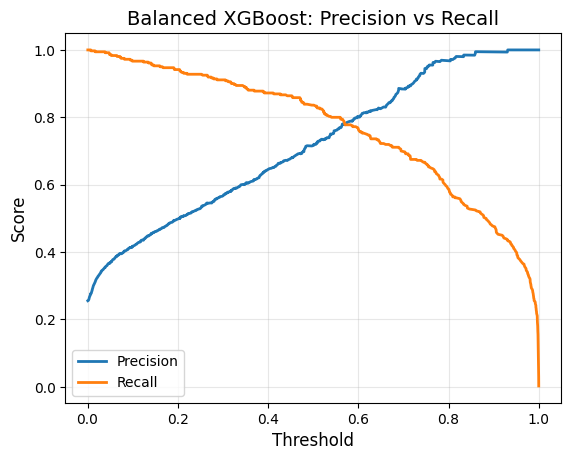

In [57]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(
    y_test,
    y_proba_w
)

plt.plot(thresholds, precisions[:-1], label='Precision', linewidth=2)
plt.plot(thresholds, recalls[:-1], label='Recall', linewidth=2)

plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)

plt.title('Balanced XGBoost: Precision vs Recall', fontsize=14)

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [61]:
# =========================
# MODELO NORMAL
# =========================

y_pred_normal = model_XGboost_GridSearch.predict(X_test)
y_proba_normal = model_XGboost_GridSearch.predict_proba(X_test)[:,1]

print("="*50)
print("XGBOOST NORMAL")
print("="*50)

print(f"Accuracy : {accuracy_score(y_test, y_pred_normal):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_normal):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_normal):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_normal):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba_normal):.4f}")


# =========================
# MODELO BALANCEADO
# =========================

y_pred_balanceado = best_GridSearchCV_xgb_w.predict(X_test)
y_proba_balanceado = best_GridSearchCV_xgb_w.predict_proba(X_test)[:,1]

print("\n" + "="*50)
print("XGBOOST BALANCEADO")
print("="*50)

print(f"Accuracy : {accuracy_score(y_test, y_pred_balanceado):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_balanceado):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_balanceado):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_balanceado):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba_balanceado):.4f}")

XGBOOST NORMAL
Accuracy : 0.8559
Precision: 0.8285
Recall   : 0.5500
F1-Score : 0.6611
ROC-AUC  : 0.9005

XGBOOST BALANCEADO
Accuracy : 0.8737
Precision: 0.7167
Recall   : 0.8361
F1-Score : 0.7718
ROC-AUC  : 0.9380


In [62]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precisions, recalls, thresholds = precision_recall_curve(
    y_test,
    y_proba_balanceado
)

# Calcular F1 para cada threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# Mejor threshold
best_threshold = thresholds[np.argmax(f1_scores[:-1])]

print("Best Threshold:", best_threshold)
print("Best F1:", np.max(f1_scores))

Best Threshold: 0.68952125
Best F1: 0.7889060091955907


In [63]:
y_pred_optimo = (y_proba_balanceado >= best_threshold).astype(int)

In [64]:
print("="*50)
print("XGBOOST BALANCEADO + THRESHOLD ÓPTIMO")
print("="*50)

print(f"Accuracy : {accuracy_score(y_test, y_pred_optimo):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_optimo):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_optimo):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_optimo):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba_balanceado):.4f}")

XGBOOST BALANCEADO + THRESHOLD ÓPTIMO
Accuracy : 0.9028
Precision: 0.8858
Recall   : 0.7111
F1-Score : 0.7889
ROC-AUC  : 0.9380


In [60]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_w))
print("Precision:", precision_score(y_test, y_pred_w))
print("Recall   :", recall_score(y_test, y_pred_w))
print("F1-score :", f1_score(y_test, y_pred_w))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_w))

Accuracy : 0.8736692689850958
Precision: 0.7166666666666667
Recall   : 0.8361111111111111
F1-score : 0.7717948717948718
ROC-AUC  : 0.937977968435547


In [66]:
comparison = pd.DataFrame({

    'Modelo': [
        'RF Original',
        'RF GridSearch',
        'RF Balanced',
        'XGBoost',
        'XGBoost Balanced'
    ],

    'Accuracy': [

        accuracy_score(y_test, y_pred_rf),

        accuracy_score(y_test, grid_search_rf.predict(X_test)),

        accuracy_score(y_test, y_pred_rf_w),

        accuracy_score(y_test, y_pred_xgb),

        accuracy_score(y_test, y_pred_balanceado)
    ],

    'Precision': [

        precision_score(y_test, y_pred_rf),

        precision_score(y_test, grid_search_rf.predict(X_test)),

        precision_score(y_test, y_pred_rf_w),

        precision_score(y_test, y_pred_xgb),

        precision_score(y_test, y_pred_balanceado)
    ],

    'Recall': [

        recall_score(y_test, y_pred_rf),

        recall_score(y_test, grid_search_rf.predict(X_test)),

        recall_score(y_test, y_pred_rf_w),

        recall_score(y_test, y_pred_xgb),

        recall_score(y_test, y_pred_balanceado)
    ],

    'F1-Score': [

        f1_score(y_test, y_pred_rf),

        f1_score(y_test, grid_search_rf.predict(X_test)),

        f1_score(y_test, y_pred_rf_w),

        f1_score(y_test, y_pred_xgb),

        f1_score(y_test, y_pred_balanceado)
    ],

    'ROC-AUC': [

        roc_auc_score(y_test, y_prob_rf),

        roc_auc_score(y_test, grid_search_rf.predict_proba(X_test)[:,1]),

        roc_auc_score(y_test, y_prob_rf_w),

        roc_auc_score(y_test, y_proba_xgb),

        roc_auc_score(y_test, y_proba_balanceado)
    ]

})

# Redondear
comparison = comparison.round(4)

# Ordenar por F1
comparison = comparison.sort_values(
    by='F1-Score',
    ascending=False
)

print(comparison)

             Modelo  Accuracy  Precision  Recall  F1-Score  ROC-AUC
4  XGBoost Balanced    0.8737     0.7167  0.8361    0.7718   0.9380
1     RF GridSearch    0.8630     0.7951  0.6250    0.6998   0.8971
2       RF Balanced    0.8602     0.8030  0.6000    0.6868   0.8944
0       RF Original    0.8559     0.7794  0.6083    0.6833   0.8934
3           XGBoost    0.8531     0.8097  0.5556    0.6590   0.8971


**Data leakage fix:** EndDate was removed before feature engineering as suggested during review. BeginDate was parsed to datetime to calculate `duration` (tenure in days) using only the snapshot date, preventing any future information from leaking into the model.

      Característica  Importancia_promedio  Desviación
4       TotalCharges              0.462224    0.016366
3     MonthlyCharges              0.308831    0.013444
17          duration              0.237428    0.014371
0               Type              0.075333    0.017438
5    InternetService              0.016154    0.010223
6     OnlineSecurity              0.003729    0.003616
11   StreamingMovies              0.003445    0.003222
13     SeniorCitizen              0.003309    0.002909
14           Partner              0.001725    0.001554
16     MultipleLines              0.000410    0.002913
12            gender              0.000405    0.002982
8   DeviceProtection              0.000171    0.002232
9        TechSupport             -0.000353    0.002977
7       OnlineBackup             -0.000391    0.003207
1   PaperlessBilling             -0.001257    0.004745
15        Dependents             -0.001374    0.002808
10       StreamingTV             -0.003247    0.004734
2      Pay

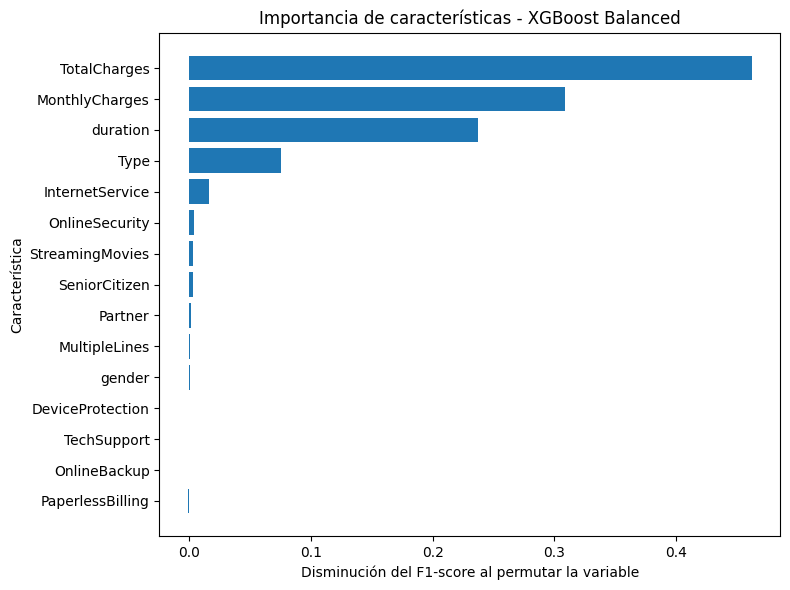

In [68]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# Mejor modelo según tu comparación
modelo_final = best_GridSearchCV_xgb_w

# Importancia por permutación usando el conjunto de prueba
result = permutation_importance(
    modelo_final,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring='f1',
    n_jobs=-1
)

importancia_df = pd.DataFrame({
    'Característica': X_test.columns,
    'Importancia_promedio': result.importances_mean,
    'Desviación': result.importances_std
}).sort_values(by='Importancia_promedio', ascending=False)

print(importancia_df)

# Gráfica de las 15 más importantes
top_features = importancia_df.head(15).sort_values('Importancia_promedio')

plt.figure(figsize=(8,6))
plt.barh(top_features['Característica'], top_features['Importancia_promedio'])
plt.xlabel('Disminución del F1-score al permutar la variable')
plt.ylabel('Característica')
plt.title('Importancia de características - XGBoost Balanced')
plt.tight_layout()
plt.show()

**Feature importance analysis:** TotalCharges was the highest-impact variable in XGBoost Balanced. Permuting this variable caused an F1-score drop of ~0.46, confirming it as the strongest churn signal. MonthlyCharges and duration (tenure) follow as second and third most important predictors.

**Solution summary:** We successfully built a supervised ML model to predict customer churn risk for the next 90 days. XGBoost Balanced achieved the best performance with ROC-AUC of 93.8% and Recall of 83.6%, correctly identifying 8 out of 10 customers at risk of canceling.

In [69]:
threshold_optimal = 0.6895

# Probabilidad de churn para toda la base
y_pred_proba_all = best_GridSearchCV_xgb_w.predict_proba(X_encoded)[:, 1]

# Clasificación usando el threshold óptimo
risk_df = df_merged.copy()
risk_df['Churn_Probability'] = y_pred_proba_all
risk_df['Churn_Prediction'] = (risk_df['Churn_Probability'] >= threshold_optimal).astype(int)

# Clientes en riesgo
at_risk_customers = risk_df[risk_df['Churn_Prediction'] == 1].copy()

# Número y porcentaje
n_riesgo = len(at_risk_customers)
porcentaje_riesgo = n_riesgo / len(risk_df) * 100

print("Clientes en riesgo:", n_riesgo)
print("Porcentaje de clientes en riesgo:", porcentaje_riesgo)

Clientes en riesgo: 1609
Porcentaje de clientes en riesgo: 22.845378389890673


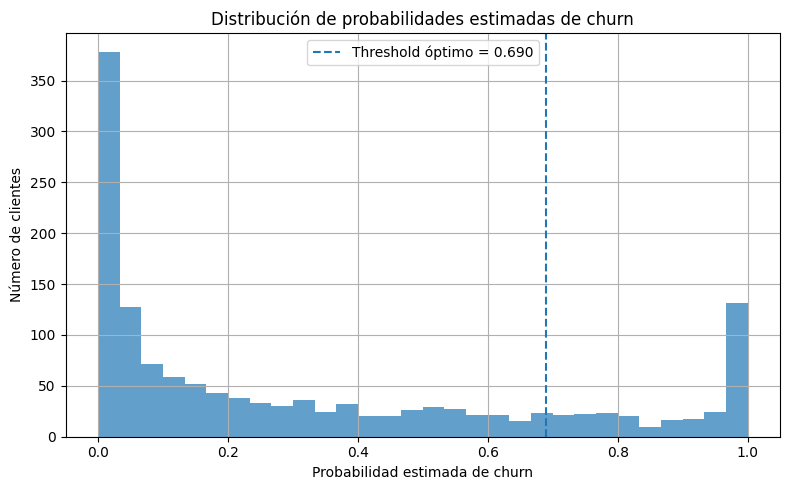

In [70]:
plt.figure(figsize=(8, 5))
plt.hist(y_proba_balanceado, bins=30, alpha=0.7)
plt.axvline(best_threshold, linestyle='--', label=f'Threshold óptimo = {best_threshold:.3f}')

plt.xlabel('Probabilidad estimada de churn')
plt.ylabel('Número de clientes')
plt.title('Distribución de probabilidades estimadas de churn')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Model deployment simulation:** Applying the XGBoost Balanced model to the full customer base with an optimal classification threshold of 0.6895, we identified **1,609 customers** with estimated churn probability ≥ threshold. These customers represent the priority list for the retention team.

**Project outcome:** We built a predictive model to identify customers at churn risk. The best-performing model was XGBoost Balanced, achieving F1-score of 0.7889 at the optimal threshold. The model is ready for integration into a retention workflow where high-risk customers receive proactive outreach.

---
## 5. Business Conclusions

### Model Results

| Model | Accuracy | Recall | F1-Score | ROC-AUC |
|---|---|---|---|---|
| RF Original | 0.856 | 0.608 | 0.683 | 0.893 |
| RF Balanced | 0.860 | 0.600 | 0.687 | 0.894 |
| RF GridSearch | 0.863 | 0.625 | 0.700 | 0.897 |
| XGBoost | 0.853 | 0.556 | 0.659 | 0.897 |
| **XGBoost Balanced** | **0.874** | **0.836** | **0.772** | **0.938** |

> **XGBoost Balanced** is the best model with **ROC-AUC of 93.8%** and **Recall of 83.6%** — meaning it correctly identifies 8 out of every 10 customers who will churn.

### Key Business Findings

1. **Contract type is the strongest behavioral predictor** — month-to-month customers churn at significantly higher rates than annual contract customers. Retention strategy: incentivize longer contracts.

2. **High charges drive churn** — customers who cancel pay more on average ($74.44 vs $61.27/month). This suggests price sensitivity is a key factor.

3. **Tenure matters** — newer customers are more likely to churn. The first 6 months are the critical retention window.

4. **Gender and demographics don't predict churn** — resources should focus on contract type and pricing strategy, not demographic segmentation.

### Recommended Actions for Retention Team

- Flag month-to-month customers with high MonthlyCharges and < 6 months tenure as high-risk
- Offer loyalty discounts or contract upgrades to customers with TotalCharges > $3,000
- Prioritize outreach to customers without OnlineSecurity or TechSupport services

---
*Project developed as part of the Data Science Diploma — TripleTen*  
*Contact: [LinkedIn](https://linkedin.com/in/david-encinas)*  
*GitHub: [github.com/DavidEncinas](https://github.com/DavidEncinas)*
